## Practice 2 
### Machine-Learning
### Myrzakassymov Azizkhan
#### Scenario
You are hired as a Data Analyst in a heavy mining company.
Management wants to implement a Predictive Maintenance System to reduce:
Unexpected machine breakdown

• Production downtime

• Safety risks

• Maintenance cost

Before Data Scientists build models, your task is:
Audit, analyze, and prepare the industrial sensor dataset for ML deployment. You are responsible for data quality, reliability, and industrial risk interpretation.

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#### Phase 1 -- Data Audit and Risk Evaluation (Industrial Thinking)

##### Task 1: Data Integrity Check

In [3]:
# Dataframe loading
df = pd.read_csv('ai4i2020.csv')

df.info()
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
# Check missing values
print("Missing values by columns:")
display(df.isnull().sum())

Missing values by columns:


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# Detect impossible values (domain reasoning):
features = ['Torque [Nm]', 'Air temperature [K]', 'Rotational speed [rpm]', 'Process temperature [K]', 'Tool wear [min]'] # columns to check
invalid_mask = (df[features] < 0).any(axis=1) 
df = df[~invalid_mask].reset_index(drop=True) # drop everything 
display(df)

# I decided to delete only rows with negative values

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [6]:
# Data preparation
features = ['Torque [Nm]', 'Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Rotational speed [rpm]']
targets = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Checking duplicated records
display(df[features].duplicated().any()) # if at least one row of features is duplicated, this will display np.True_

# Checking inconsistent failure flags 
decimals = pd.Series([0, 0, 0, 0, -1], index=features) # rounding each to closest integer and for rotational speed to closest decimal 
approx = df.round(decimals) # approximate dataset

conflicting_rows = approx[
    (approx.groupby(features)['Machine failure'].transform('nunique') > 1 ) |
    (approx.groupby(features)['TWF'].transform('nunique') > 1) | 
    (approx.groupby(features)['HDF'].transform('nunique') > 1) |
    (approx.groupby(features)['PWF'].transform('nunique') > 1) | 
    (approx.groupby(features)['OSF'].transform('nunique') > 1) | 
    (approx.groupby(features)['RNF'].transform('nunique') > 1) 
    # aggregates by features, sees if any form of machine failure occured twice  for same input
]


display(conflicting_rows)
del conflicting_rows, approx, decimals, features, targets

np.False_

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


We can see that even approximately, there's no inconsistent failure flags.

As we can see, there's no duplicated records in this dataframe, no missing values, domain reasoning isn't violated and there's no inconsistent failure flags, dataset is **clean**.

**Risks** 
If this data feeds a real-time control system, risks is:
- Low amount of data, it can be that classification model won't estimate failure accurate enough
- Because data is consistent with values, extreme intput can lead to mispredict by model
- Might be that sensors were showing different values in moment of failure, but computer didn't catch up to write it
- There might be missing variables that could lead to failure
- If models has poor F1-score, Precision or Recall, it can stop machine (money-loss) by no reason, better safe than sorry, but it also can NOT stop when it needed.

#### Phase 2 -- Sensor Behavior Analysis
You must treat each variable as a real industrial sensor

For each numeric feature:

1. Analyze distribution.
2. Compute dispersion (std, IQR).
3. Identify extreme operating zones.
4. Compare sensor behavior for:
- Normal machines
- Failed machines

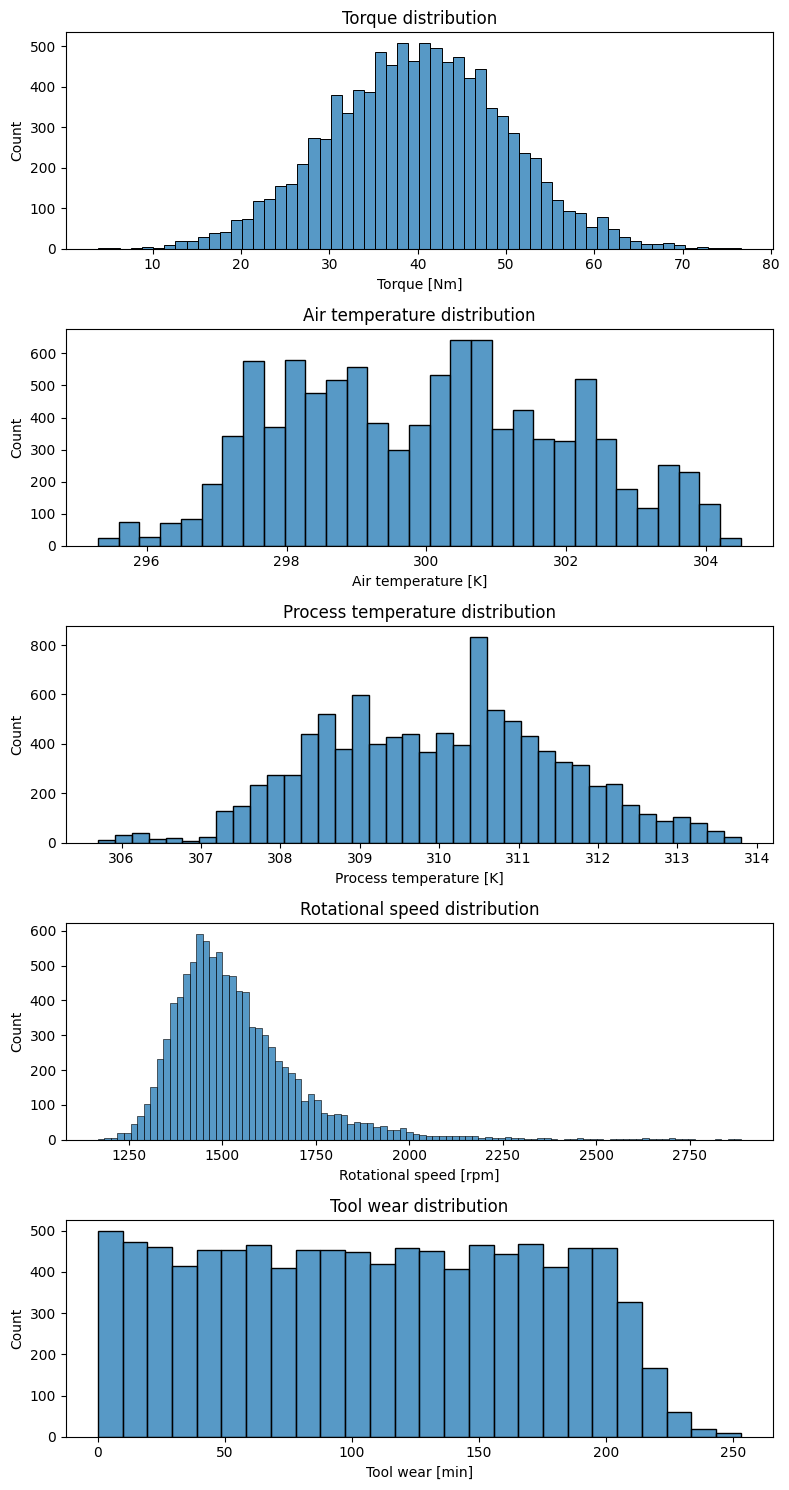

In [7]:
# Distributions

# data preparation
graphs = {
    'Torque' : df['Torque [Nm]'],
    'Air temperature' : df['Air temperature [K]'],
    'Process temperature' : df['Process temperature [K]'],
    'Rotational speed' : df['Rotational speed [rpm]'],
    'Tool wear' : df['Tool wear [min]']
}

fig, ax = plt.subplots(nrows=5, ncols=1, sharex=False, figsize=(8, 15))
for graph, i in zip(graphs, range(0, 5)):
    sns.histplot(data=graphs[graph], ax=ax[i])
    title = graph + ' distribution'
    ax[i].set_title(title)

plt.tight_layout()
plt.show

del graphs, fig, ax

**Assumptions**

Torque is most likely normally distributed (it's a continous variable);

Rotational speed is probably distributed by Poisson distribtuion with low lambda parameter;

Tool wear could be distributed uniformly (though for values after 200 frequencies are very low);

Air and Process temperature could be normally distributed variables.

In [8]:
# Dispersion, IQR and extreme operating zones
cols_to_check = {
    'Torque' : df['Torque [Nm]'],
    'Air temperature' : df['Air temperature [K]'],
    'Process temperature' : df['Process temperature [K]'],
    'Rotational speed' : df['Rotational speed [rpm]'],
    'Tool wear' : df['Tool wear [min]']
}

for col in cols_to_check:
    mean = cols_to_check[col].mean()
    median = cols_to_check[col].median()
    std = cols_to_check[col].std()
    q1 = np.percentile(cols_to_check[col], 25)
    q3 = np.percentile(cols_to_check[col], 75)
    iqr = q3 - q1
    extreme_zones_l = q1 - iqr * 1.5
    extreme_zones_u = q3 + iqr * 1.5

    print(f'{col}\n Mean: {mean},\n Median: {median}, \n Standart Deviation: {std}, \n IQR: {iqr}, \n Extreme Operating Zones: {extreme_zones_l}, {extreme_zones_u}')

del cols_to_check, mean, std, iqr, extreme_zones_l, extreme_zones_u

Torque
 Mean: 39.986909999999995,
 Median: 40.1, 
 Standart Deviation: 9.968933725121337, 
 IQR: 13.599999999999994, 
 Extreme Operating Zones: 12.800000000000011, 67.19999999999999
Air temperature
 Mean: 300.00493,
 Median: 300.1, 
 Standart Deviation: 2.0002586829157516, 
 IQR: 3.1999999999999886, 
 Extreme Operating Zones: 293.5, 306.29999999999995
Process temperature
 Mean: 310.00555999999995,
 Median: 310.1, 
 Standart Deviation: 1.4837342191657208, 
 IQR: 2.3000000000000114, 
 Extreme Operating Zones: 305.35, 314.55000000000007
Rotational speed
 Mean: 1538.7761,
 Median: 1503.0, 
 Standart Deviation: 179.2840959134266, 
 IQR: 189.0, 
 Extreme Operating Zones: 1139.5, 1895.5
Tool wear
 Mean: 107.951,
 Median: 108.0, 
 Standart Deviation: 63.65414663663636, 
 IQR: 109.0, 
 Extreme Operating Zones: -110.5, 325.5


In [9]:
features = ['Torque [Nm]', 'Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Rotational speed [rpm]']
targets = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failed = df[df[targets].gt(0).any(axis=1)] # failed machines
normal = df[df[targets].eq(0).all(axis=1)] # normal machines

print('Statistics for failed machines:')
display(failed[features].agg(['mean', 'median', 'std', 'sem']))

print('Statistics for normal machines')
display(normal[features].agg(['mean', 'median', 'std', 'sem']))
del (failed, normal, features, targets)


Statistics for failed machines:


,Torque [Nm],Air temperature [K],Process temperature [K],Tool wear [min],Rotational speed [rpm]
mean,49.833053,300.880392,310.313725,142.577031,1496.131653
median,53.200000,301.600000,310.500000,163.000000,1366.000000
std,16.196335,2.054225,1.372465,72.650679,375.869908
sem,0.857201,0.108721,0.072639,3.845082,19.893145


Statistics for normal machines


,Torque [Nm],Air temperature [K],Process temperature [K],Tool wear [min],Rotational speed [rpm]
mean,39.622389,299.972519,309.994151,106.669086,1540.354869
median,39.800000,300.000000,310.000000,107.000000,1507.000000
std,9.468446,1.990965,1.486534,62.936149,167.471848
sem,0.096421,0.020275,0.015138,0.640906,1.705437


As we can see, columns that has different mean and medians are Torque, Tool wear and Rotational speed, we can also use ANOVA, t-tets for normal and failed tables to see if their divergence statistically sufficient.

#### PHASE 3 -- Industrial Anomaly Detection

Instead of just removing outliers:
1. Detect anomalies using:
- Z-score
- IQR
2. Compare anomaly records with failure label.
Questions:
- Are anomalies noise or early breakdown signals?
- Should we remove them or mark them as risk indicators?
Deliverable:
Decision with justification.

In [ ]:
features = ['Torque [Nm]', 'Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Rotational speed [rpm]']

# z-score 
z_scored = df[features].apply(zscore) # z-score, though, can be applied only on normally distributed data
z_scored_extreme = df[
    (z_scored[features].gt(1.96).any(axis=1)) 
    | (z_scored[features].lt(-1.96).any(axis=1))
]# for 47.5 percents outliers for each side I will use 1.96
# if at least one feature has outlied row, then it goes to z_scored_extreme

# IQR
q1 = df[features].quantile(0.25)
q3 = df[features].quantile(0.75)
iqr = q3 - q1

lowerbound = q1 - 1.5 * iqr
upperbound = q3 + 1.5 * iqr
iqr_extreme = df[
    (df[features].lt(lowerbound).any(axis=1)) 
    | (df[features].gt(upperbound).any(axis=1))]

# displaying 
display('Z-score:', z_scored_extreme)
display('IQR:', iqr_extreme)

del(features, z_scored, iqr, q1, q3, lowerbound, upperbound)

'Z-score:'

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
14,15,L47194,L,298.6,309.2,2035,19.6,40,0,0,0,0,0,0
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
70,71,M14930,M,298.9,309.0,1924,22.6,193,0,0,0,0,0,0
101,102,L47281,L,298.8,308.8,1991,20.7,59,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9886,9887,L57066,L,298.8,309.6,1903,22.3,145,0,0,0,0,0,0
9926,9927,M24786,M,298.5,308.6,1897,20.2,50,0,0,0,0,0,0
9939,9940,H39353,H,298.3,308.1,2636,12.8,84,0,0,0,0,0,0
9970,9971,H39384,H,298.4,308.1,1891,24.7,158,0,0,0,0,0,0


'IQR:'

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
14,15,L47194,L,298.6,309.2,2035,19.6,40,0,0,0,0,0,0
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
70,71,M14930,M,298.9,309.0,1924,22.6,193,0,0,0,0,0,0
101,102,L47281,L,298.8,308.8,1991,20.7,59,0,0,0,0,0,0
155,156,H29569,H,298.4,308.2,1987,19.8,198,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9871,9872,M24731,M,298.9,309.8,1947,21.7,105,0,0,0,0,0,0
9886,9887,L57066,L,298.8,309.6,1903,22.3,145,0,0,0,0,0,0
9926,9927,M24786,M,298.5,308.6,1897,20.2,50,0,0,0,0,0,0
9939,9940,H39353,H,298.3,308.1,2636,12.8,84,0,0,0,0,0,0


As we can see, z-score took more outliers than IQR, a lot more. The reason behind isn't only distributions but also the fact that it takes any row with outlier in it.

In [54]:
targets = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

iqr_extreme_failed = iqr_extreme[iqr_extreme[targets].gt(0).any(axis=1)]
z_scored_extreme_failed = z_scored_extreme[z_scored_extreme[targets].gt(0).any(axis=1)]

display('Z-scored outliers failed machines', z_scored_extreme_failed, 'IQR outliers failed machines', iqr_extreme_failed)

print("Percent of outliers being broken for Z-score:", len(z_scored_extreme_failed)/len(z_scored_extreme) * 100, '%')
print("Percent of outliers being broken for IQR:", len(iqr_extreme_failed)/len(iqr_extreme) * 100, '%')
del targets

'Z-scored outliers failed machines'

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
168,169,L47348,L,298.4,308.3,1433,62.3,20,1,0,0,1,0,0
194,195,M15054,M,298.2,308.5,2678,10.7,86,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,9668,L56847,L,299.2,310.3,1352,48.9,238,1,0,0,0,1,0
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,1,0,0,0,0
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1,0,0,1,0,0
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1,0,0,0,1,0


'IQR outliers failed machines'

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
194,195,M15054,M,298.2,308.5,2678,10.7,86,1,0,0,1,0,0
380,381,L47560,L,297.5,308.3,2564,12.8,127,1,0,0,1,0,0
463,464,L47643,L,297.4,308.7,2874,4.2,118,1,0,0,1,0,0
603,604,L47783,L,297.9,309.8,1336,71.6,31,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8582,8583,M23442,M,297.5,308.1,1334,72.0,151,1,0,0,1,0,0
9084,9085,L56264,L,297.2,307.9,1326,75.4,172,1,0,0,1,1,0
9576,9577,L56756,L,299.6,310.7,1922,23.3,205,1,1,0,0,0,0
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,1,0,0,0,0


Percent of outliers being broken for Z-score: 14.272388059701493 %
Percent of outliers being broken for IQR: 15.686274509803921 %


It's interesting that Z-score has double of elements compared to IQR, by Z-score approximately half of all machine broken caused by some sort of outliers from features.
Though, IQR has more percentage, which is also interesting. 
To know if outliers are noise or not we should analyze dataset further (like using Z-score only on normally distributed data), though 